# Customer Retention & Churn Analysis
### IBM Telco Customer Churn Dataset

**Author:** Data Analytics Intern — Future Interns Task 2
**Objective:** Analyze customer churn patterns, identify key retention drivers, and produce actionable business insights and KPIs for a telecom provider.

---

## Table of Contents
1. [Introduction](#1)
2. [Imports](#2)
3. [Dataset Loading](#3)
4. [Data Cleaning](#4)
5. [Exploratory Data Analysis](#5)
6. [KPI Analysis](#6)
7. [Cohort Analysis](#7)
8. [Customer Lifetime Analysis](#8)
9. [Churn Trend Analysis](#9)
10. [Business Insights](#10)
11. [Business Recommendations](#11)
12. [Conclusion](#12)


<a id='1'></a>
## 1. Introduction

Customer churn — when a customer stops doing business with a company — is one of the most expensive problems a subscription-based business can face. Acquiring a new customer typically costs far more than retaining an existing one, which makes understanding **why** customers leave a high-value analytics problem.

This notebook analyzes the **IBM Telco Customer Churn dataset**, which contains demographic, account, and service-usage information for **7,043 customers** of a fictional telecom company, along with whether each customer churned in the last month.

**Business questions this analysis answers:**
- What does the customer base look like, and how many customers are churning?
- Which customer segments (contract type, tenure, payment method, services) are most likely to churn?
- What is the revenue impact of churn?
- What actionable retention strategies can be recommended to the business?


<a id='2'></a>
## 2. Imports

We use `pandas`/`numpy` for data manipulation, `matplotlib`/`seaborn` for visualization, and `scikit-learn`'s `LabelEncoder` for preparing categorical fields for the correlation analysis.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import json
import warnings

warnings.filterwarnings("ignore")

# Visualization styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

CHURN_COLORS = {"No": "#2E86AB", "Yes": "#E63946"}
PALETTE = ["#2E86AB", "#E63946", "#F4A261", "#2A9D8F", "#264653", "#E9C46A"]

DATA_PATH = "../data/Telco_Customer_Churn.csv"
IMG_DIR = "../images"
print("Libraries loaded successfully.")

Libraries loaded successfully.


<a id='3'></a>
## 3. Dataset Loading

> **Data source:** This notebook uses the original **IBM Telco Customer Churn** dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`), sourced from IBM's official public GitHub repository (21 columns, 7,043 customers, 26.54% churn rate). No synthetic or modified data is used anywhere in this analysis.

In [70]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [72]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a id='4'></a>
## 4. Data Cleaning

Steps performed:
1. Remove duplicate `customerID` rows
2. Clean and convert `TotalCharges` (stored as text in the raw file, with blank strings for brand-new customers)
3. Impute missing values sensibly (0 for zero-tenure customers, estimated otherwise)
4. Correct data types (`SeniorCitizen` 0/1 → Yes/No, numeric casts)
5. Engineer new features: `TenureGroup`, `ChargeGroup`, `NumAddOnServices`, `IsNewCustomer`, `CLV_Estimate`
6. Encode categorical variables for correlation analysis

In [73]:
# 4.1 Remove duplicates
before = len(df)
df = df.drop_duplicates(subset="customerID", keep="first")
print(f"Removed {before - len(df)} duplicate customerID rows")

# 4.2 Clean TotalCharges
df["TotalCharges"] = df["TotalCharges"].astype(str).str.strip().replace("", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# 4.3 Handle missing values
new_customer_mask = (df["TotalCharges"].isna()) & (df["tenure"] == 0)
df.loc[new_customer_mask, "TotalCharges"] = 0.0

remaining_missing = df["TotalCharges"].isna()
df.loc[remaining_missing, "TotalCharges"] = (
    df.loc[remaining_missing, "MonthlyCharges"] * df.loc[remaining_missing, "tenure"]
)

print("Missing values remaining:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None ✅")

Removed 0 duplicate customerID rows
Missing values remaining:
None ✅


In [74]:
# 4.4 Correct data types
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["tenure"] = df["tenure"].astype(int)
df["MonthlyCharges"] = df["MonthlyCharges"].astype(float)
df["TotalCharges"] = df["TotalCharges"].astype(float).round(2)
df.dtypes

customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [75]:
# 4.5 Feature engineering
def tenure_group(t):
    if t <= 12: return "0-1 Year"
    elif t <= 24: return "1-2 Years"
    elif t <= 48: return "2-4 Years"
    elif t <= 60: return "4-5 Years"
    else: return "5+ Years"

df["TenureGroup"] = pd.Categorical(
    df["tenure"].apply(tenure_group),
    categories=["0-1 Year", "1-2 Years", "2-4 Years", "4-5 Years", "5+ Years"],
    ordered=True,
)

def charge_group(c):
    if c < 35: return "Low (<$35)"
    elif c < 70: return "Medium ($35-70)"
    elif c < 100: return "High ($70-100)"
    else: return "Very High (>$100)"

df["ChargeGroup"] = df["MonthlyCharges"].apply(charge_group)

addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["NumAddOnServices"] = (df[addon_cols] == "Yes").sum(axis=1)
df["IsNewCustomer"] = df["tenure"] <= 6
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
df["CLV_Estimate"] = (df["MonthlyCharges"] * 24).round(2)

df[["tenure", "TenureGroup", "MonthlyCharges", "ChargeGroup", "NumAddOnServices", "CLV_Estimate"]].head()

,tenure,TenureGroup,MonthlyCharges,ChargeGroup,NumAddOnServices,CLV_Estimate
0,1,0-1 Year,29.85,Low (<$35),1,716.4
1,34,2-4 Years,56.95,Medium ($35-70),2,1366.8
2,2,0-1 Year,53.85,Medium ($35-70),2,1292.4
3,45,2-4 Years,42.30,Medium ($35-70),3,1015.2
4,2,0-1 Year,70.70,High ($70-100),0,1696.8


In [76]:
# 4.6 Encode categorical variables (for correlation heatmap only; original columns are kept for EDA)
df_encoded = df.copy()
binary_map = {"Yes": 1, "No": 0}
for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn", "SeniorCitizen"]:
    df_encoded[col] = df_encoded[col].map(binary_map)
df_encoded["gender"] = df_encoded["gender"].map({"Male": 1, "Female": 0})

cat_cols_multi = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                   "Contract", "PaymentMethod", "TenureGroup", "ChargeGroup"]
le = LabelEncoder()
for col in cat_cols_multi:
    df_encoded[col + "_enc"] = le.fit_transform(df_encoded[col].astype(str))

print("Cleaned dataset shape:", df.shape)
df.to_csv("../data/Telco_Customer_Churn_Cleaned.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset shape: (7043, 27)
Cleaned dataset saved.


<a id='5'></a>
## 5. Exploratory Data Analysis

We now visualize churn patterns across demographics, account attributes, and services. Every chart is also saved to `../images/` at high resolution for use in the README, report, and dashboard.

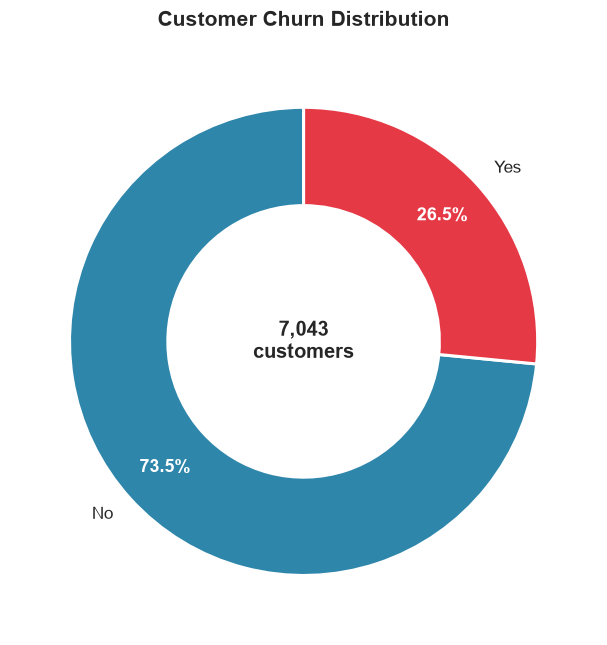

In [77]:
# 5.1 Overall churn distribution
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["Churn"].value_counts()
wedges, texts, autotexts = ax.pie(
    counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
    colors=[CHURN_COLORS[c] for c in counts.index],
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2), pctdistance=0.80,
)
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold"); t.set_fontsize(12)
ax.set_title("Customer Churn Distribution", pad=15)
ax.text(0, 0, f"{len(df):,}\ncustomers", ha="center", va="center", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/churn_distribution.png", bbox_inches="tight")
plt.show()

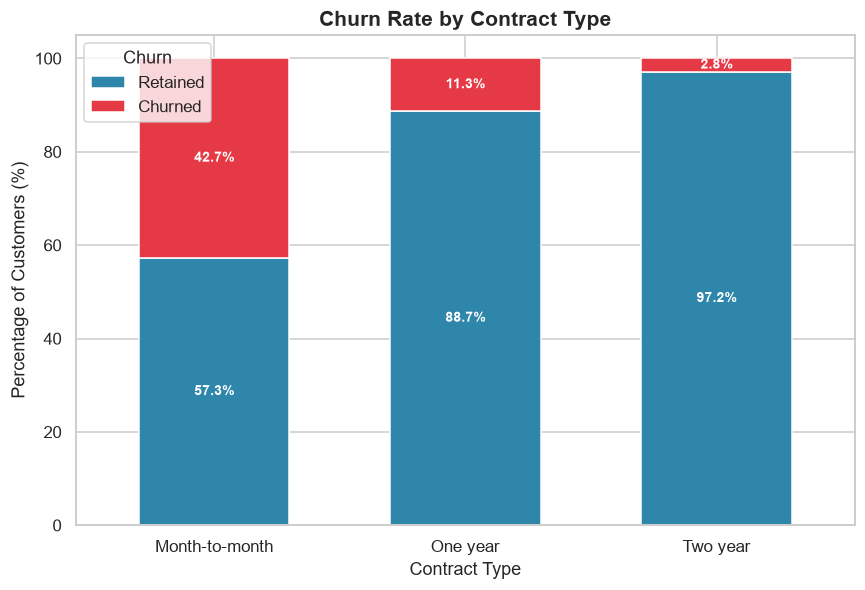

In [78]:
# 5.2 Churn by contract type
fig, ax = plt.subplots(figsize=(8, 5.5))
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index").mul(100)[["No", "Yes"]]
ct.plot(kind="bar", stacked=True, color=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]], ax=ax, width=0.6)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract Type"); ax.set_ylabel("Percentage of Customers (%)")
ax.legend(title="Churn", labels=["Retained", "Churned"])
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", color="white", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/contract_analysis.png", bbox_inches="tight")
plt.show()

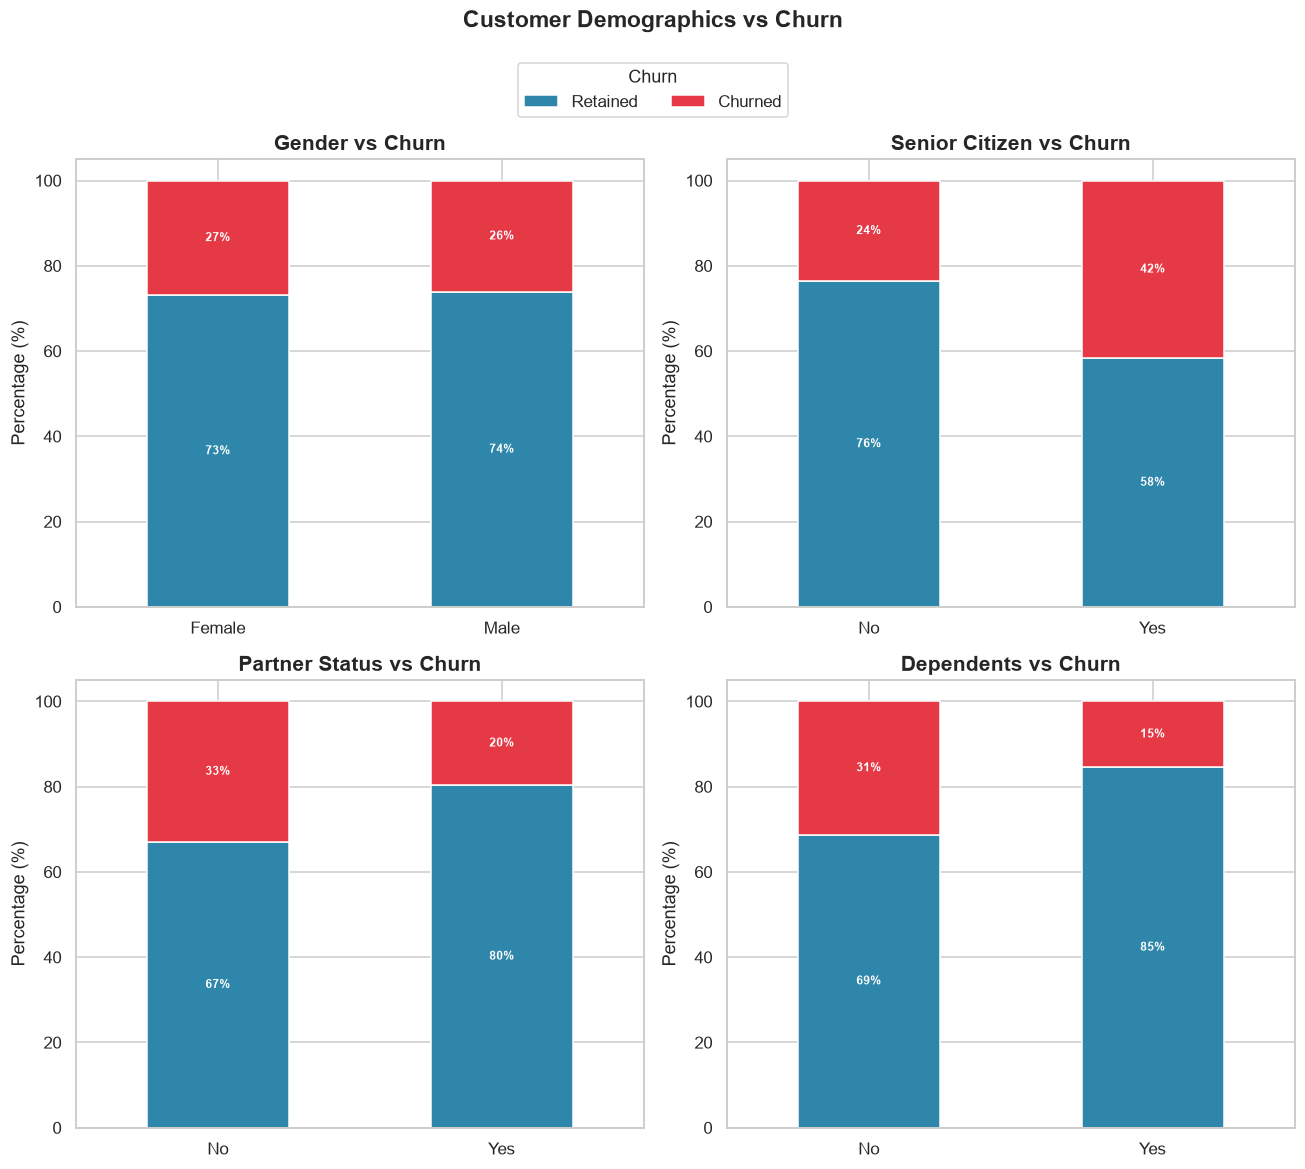

In [79]:
# 5.3 Demographics vs churn (gender, senior citizen, partner, dependents)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
demo_cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]
titles = ["Gender vs Churn", "Senior Citizen vs Churn", "Partner Status vs Churn", "Dependents vs Churn"]
for ax, col, title in zip(axes.flat, demo_cols, titles):
    ctab = pd.crosstab(df[col], df["Churn"], normalize="index").mul(100)[["No", "Yes"]]
    ctab.plot(kind="bar", stacked=True, color=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]], ax=ax, legend=False)
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("Percentage (%)")
    ax.tick_params(axis="x", rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f%%", label_type="center", color="white", fontweight="bold", fontsize=8)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["Retained", "Churned"], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02), title="Churn")
fig.suptitle("Customer Demographics vs Churn", fontsize=15, fontweight="bold", y=1.06)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/demographics_vs_churn.png", bbox_inches="tight")
plt.show()

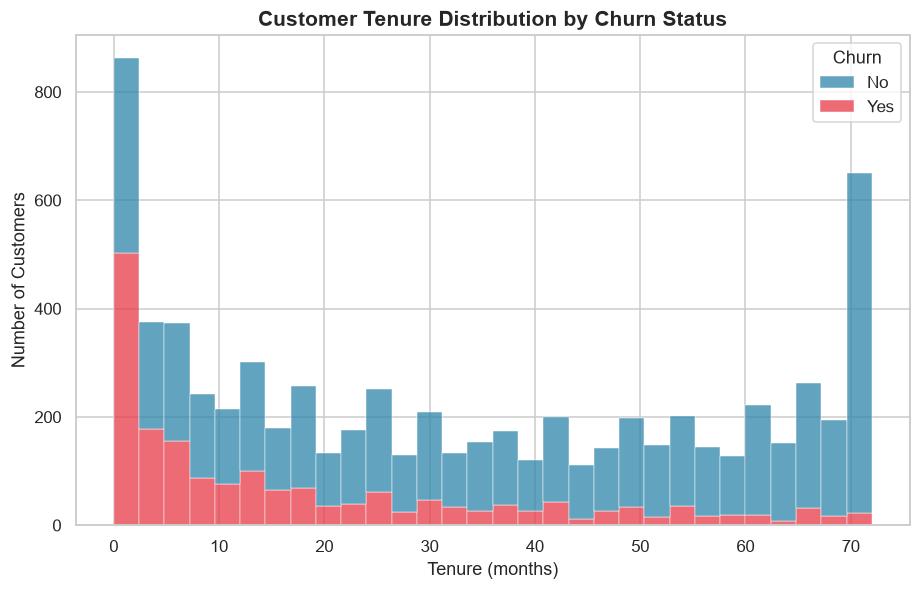

In [80]:
# 5.4 Tenure distribution by churn
fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack",
             palette=CHURN_COLORS, bins=30, ax=ax, edgecolor="white", linewidth=0.3)
ax.set_title("Customer Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/tenure_analysis.png", bbox_inches="tight")
plt.show()

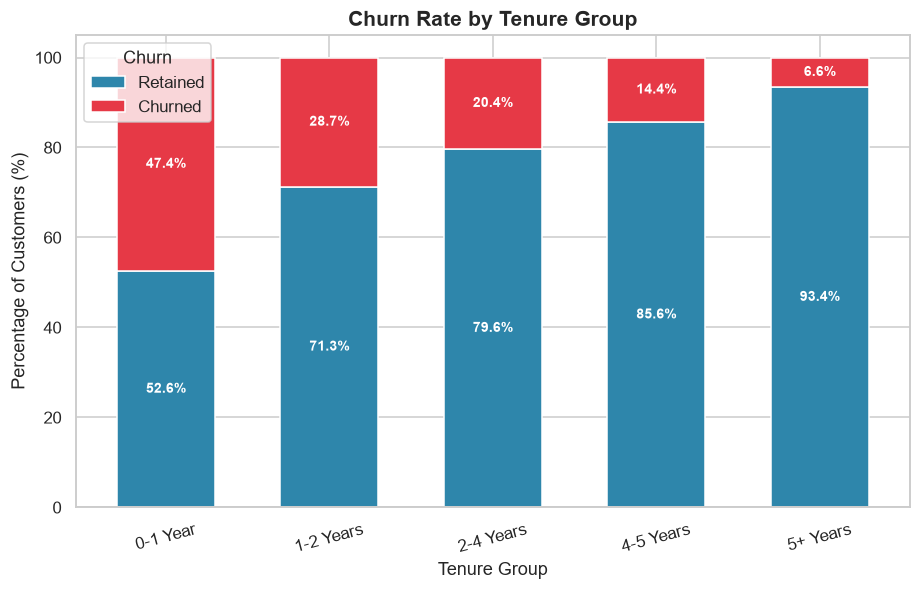

In [81]:
# 5.5 Churn rate by tenure group
fig, ax = plt.subplots(figsize=(8.5, 5.5))
tg = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index").mul(100)[["No", "Yes"]]
tg.plot(kind="bar", stacked=True, color=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]], ax=ax, width=0.6)
ax.set_title("Churn Rate by Tenure Group")
ax.set_xlabel("Tenure Group"); ax.set_ylabel("Percentage of Customers (%)")
ax.legend(title="Churn", labels=["Retained", "Churned"])
plt.xticks(rotation=15)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", color="white", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/tenure_group_churn.png", bbox_inches="tight")
plt.show()

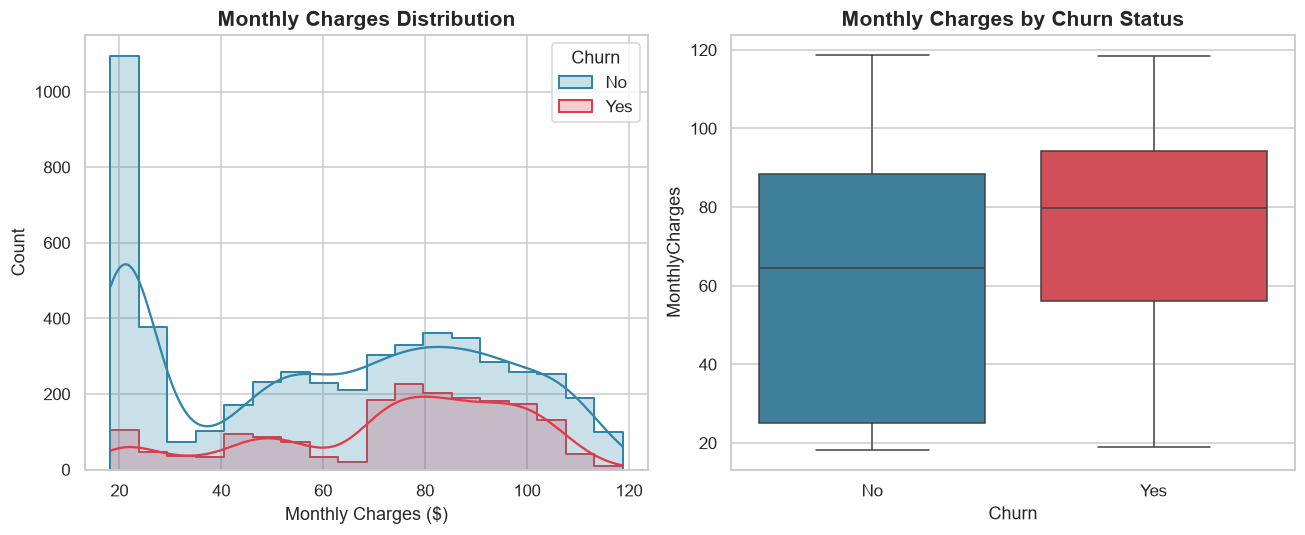

In [82]:
# 5.6 Monthly charges distribution & boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn", kde=True, palette=CHURN_COLORS,
             ax=axes[0], element="step", linewidth=1.3)
axes[0].set_title("Monthly Charges Distribution"); axes[0].set_xlabel("Monthly Charges ($)")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=CHURN_COLORS, ax=axes[1])
axes[1].set_title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/monthly_charges.png", bbox_inches="tight")
plt.show()

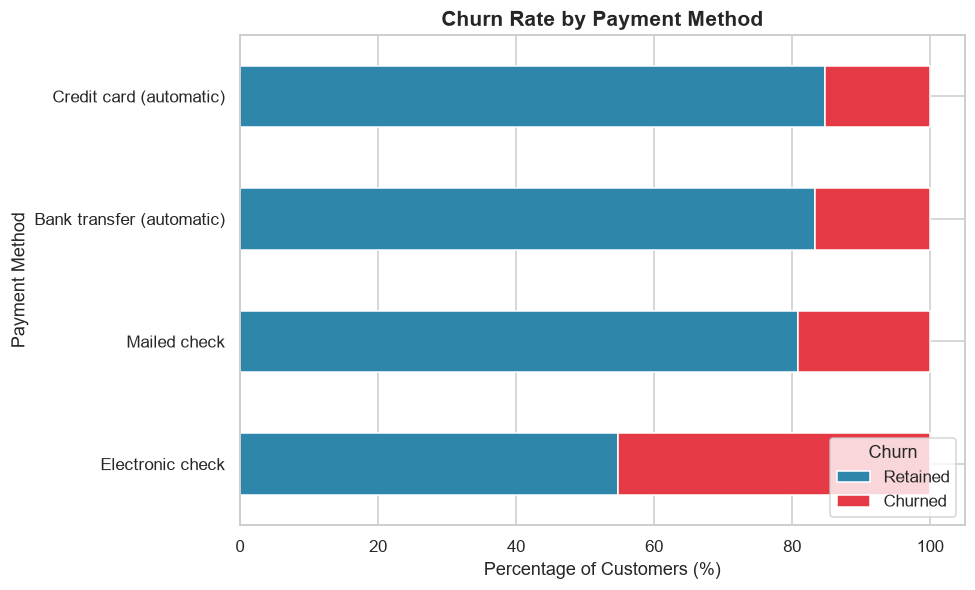

In [83]:
# 5.7 Payment method vs churn
fig, ax = plt.subplots(figsize=(9, 5.5))
pm = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index").mul(100)[["No", "Yes"]]
pm = pm.sort_values("Yes", ascending=False)
pm.plot(kind="barh", stacked=True, color=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]], ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Percentage of Customers (%)"); ax.set_ylabel("Payment Method")
ax.legend(title="Churn", labels=["Retained", "Churned"], loc="lower right")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/payment_method.png", bbox_inches="tight")
plt.show()

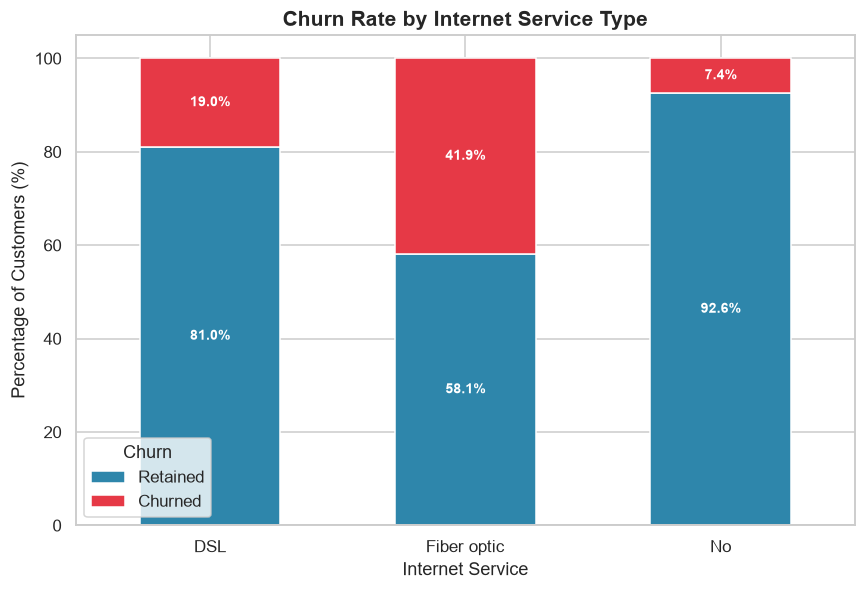

In [84]:
# 5.8 Internet service vs churn
fig, ax = plt.subplots(figsize=(8, 5.5))
ins = pd.crosstab(df["InternetService"], df["Churn"], normalize="index").mul(100)[["No", "Yes"]]
ins.plot(kind="bar", stacked=True, color=[CHURN_COLORS["No"], CHURN_COLORS["Yes"]], ax=ax, width=0.55)
ax.set_title("Churn Rate by Internet Service Type")
ax.set_xlabel("Internet Service"); ax.set_ylabel("Percentage of Customers (%)")
ax.legend(title="Churn", labels=["Retained", "Churned"])
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", color="white", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/internet_service.png", bbox_inches="tight")
plt.show()

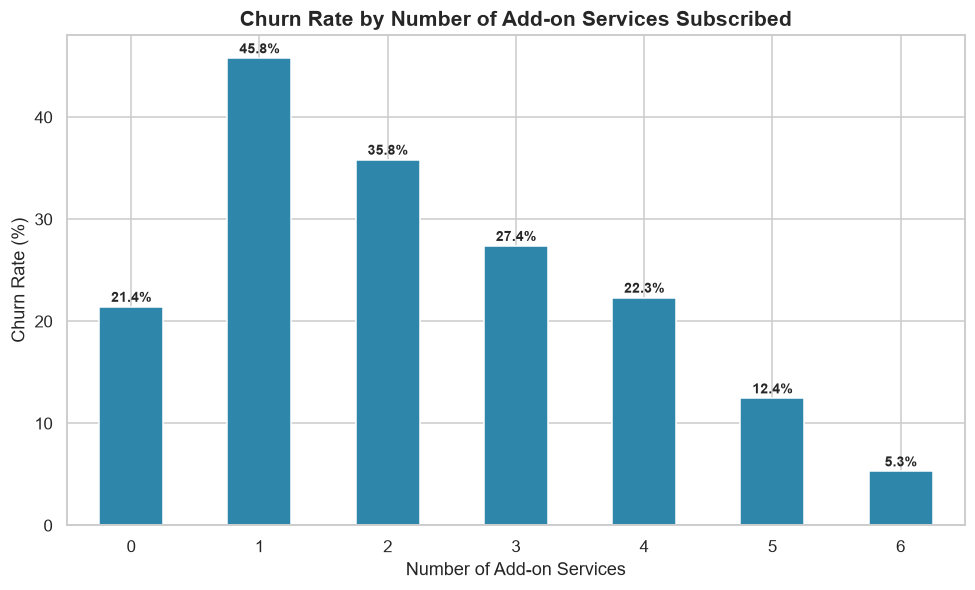

In [85]:
# 5.9 Add-on services vs churn
fig, ax = plt.subplots(figsize=(9, 5.5))
addon_churn = df.groupby("NumAddOnServices")["ChurnFlag"].mean().mul(100)
addon_churn.plot(kind="bar", color=PALETTE[0], ax=ax, edgecolor="white")
ax.set_title("Churn Rate by Number of Add-on Services Subscribed")
ax.set_xlabel("Number of Add-on Services"); ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
for i, v in enumerate(addon_churn):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/addon_services_churn.png", bbox_inches="tight")
plt.show()

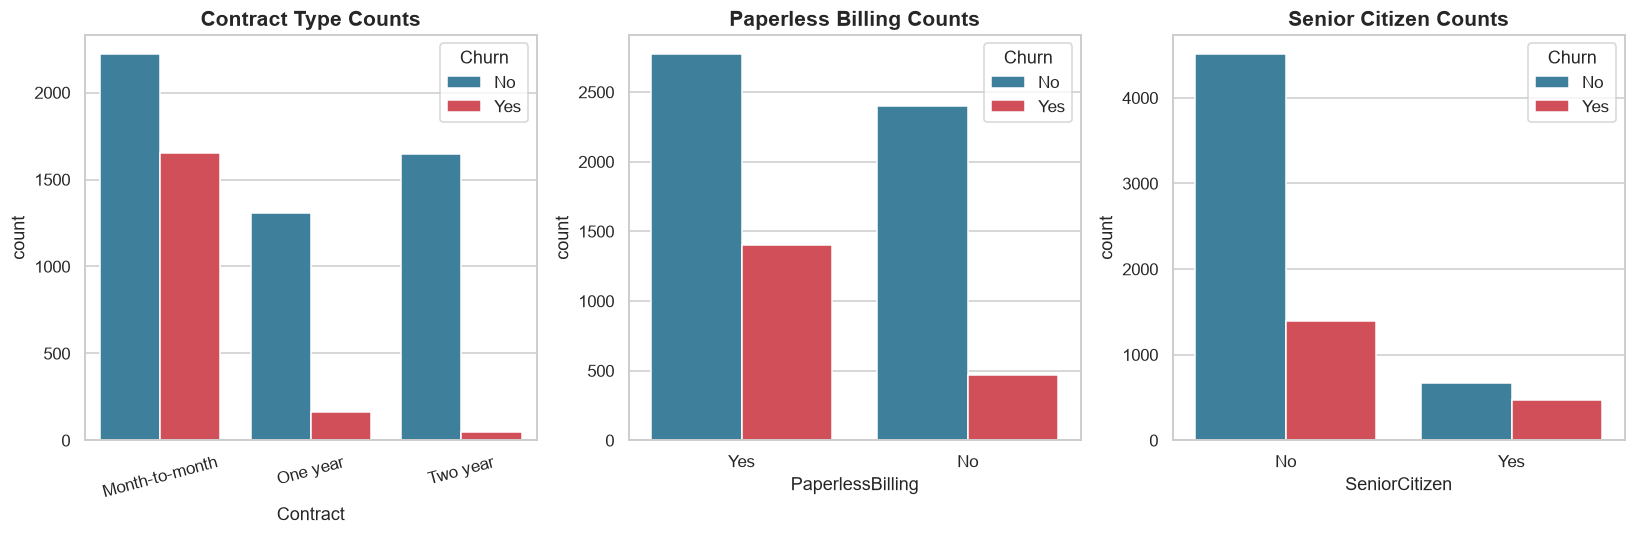

In [86]:
# 5.10 Countplots overview
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette=CHURN_COLORS, ax=axes[0])
axes[0].set_title("Contract Type Counts"); axes[0].tick_params(axis="x", rotation=15)
sns.countplot(data=df, x="PaperlessBilling", hue="Churn", palette=CHURN_COLORS, ax=axes[1])
axes[1].set_title("Paperless Billing Counts")
sns.countplot(data=df, x="SeniorCitizen", hue="Churn", palette=CHURN_COLORS, ax=axes[2])
axes[2].set_title("Senior Citizen Counts")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/countplots_overview.png", bbox_inches="tight")
plt.show()

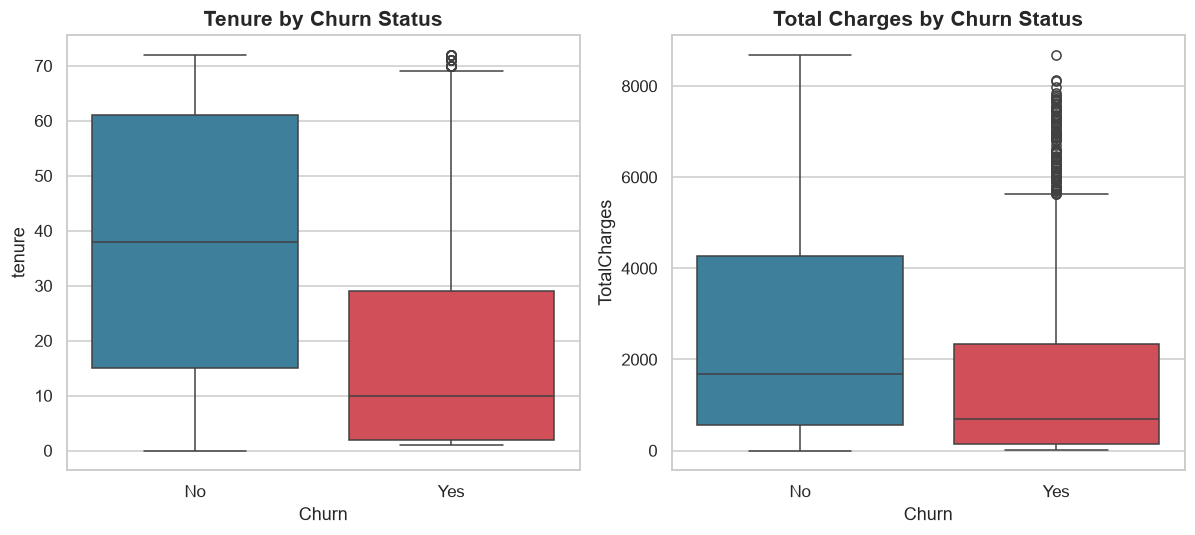

In [87]:
# 5.11 Boxplots: tenure & total charges by churn
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(data=df, x="Churn", y="tenure", palette=CHURN_COLORS, ax=axes[0])
axes[0].set_title("Tenure by Churn Status")
sns.boxplot(data=df, x="Churn", y="TotalCharges", palette=CHURN_COLORS, ax=axes[1])
axes[1].set_title("Total Charges by Churn Status")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/boxplots_tenure_totalcharges.png", bbox_inches="tight")
plt.show()

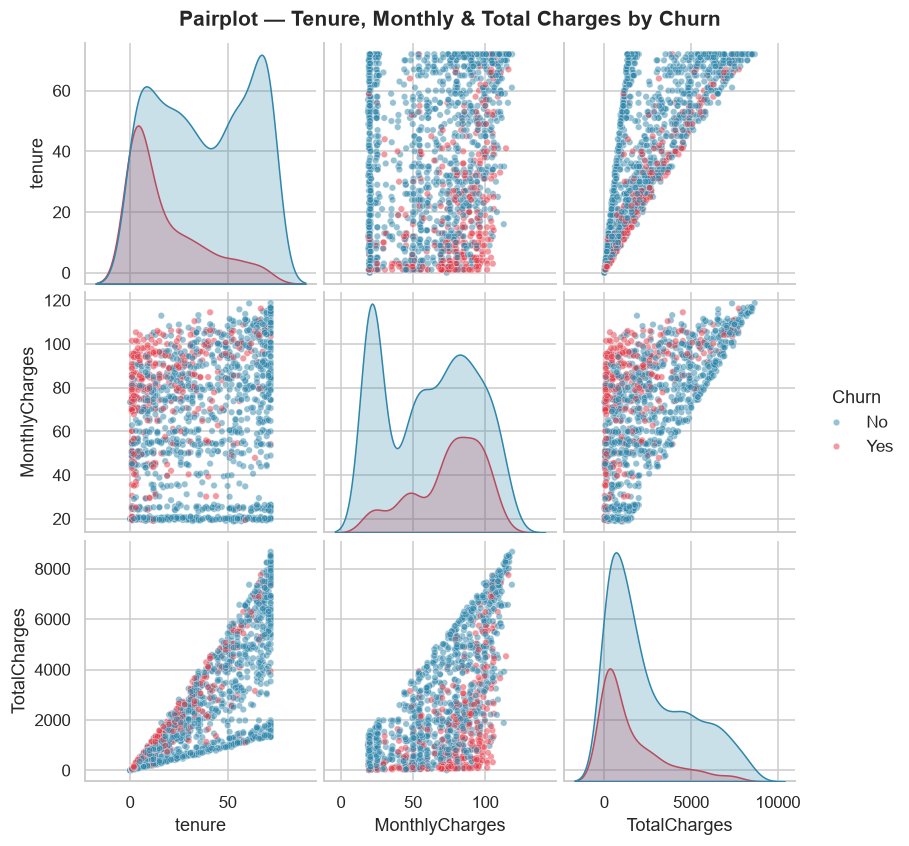

In [88]:
# 5.12 Pairplot of numeric relationships (sampled for performance)
sample_df = df.sample(min(1500, len(df)), random_state=1)
pp = sns.pairplot(
    sample_df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]],
    hue="Churn", palette=CHURN_COLORS, plot_kws={"alpha": 0.5, "s": 18}, diag_kind="kde"
)
pp.fig.suptitle("Pairplot — Tenure, Monthly & Total Charges by Churn", y=1.02, fontsize=14, fontweight="bold")
pp.savefig(f"{IMG_DIR}/pairplot_numeric.png", bbox_inches="tight")
plt.show()

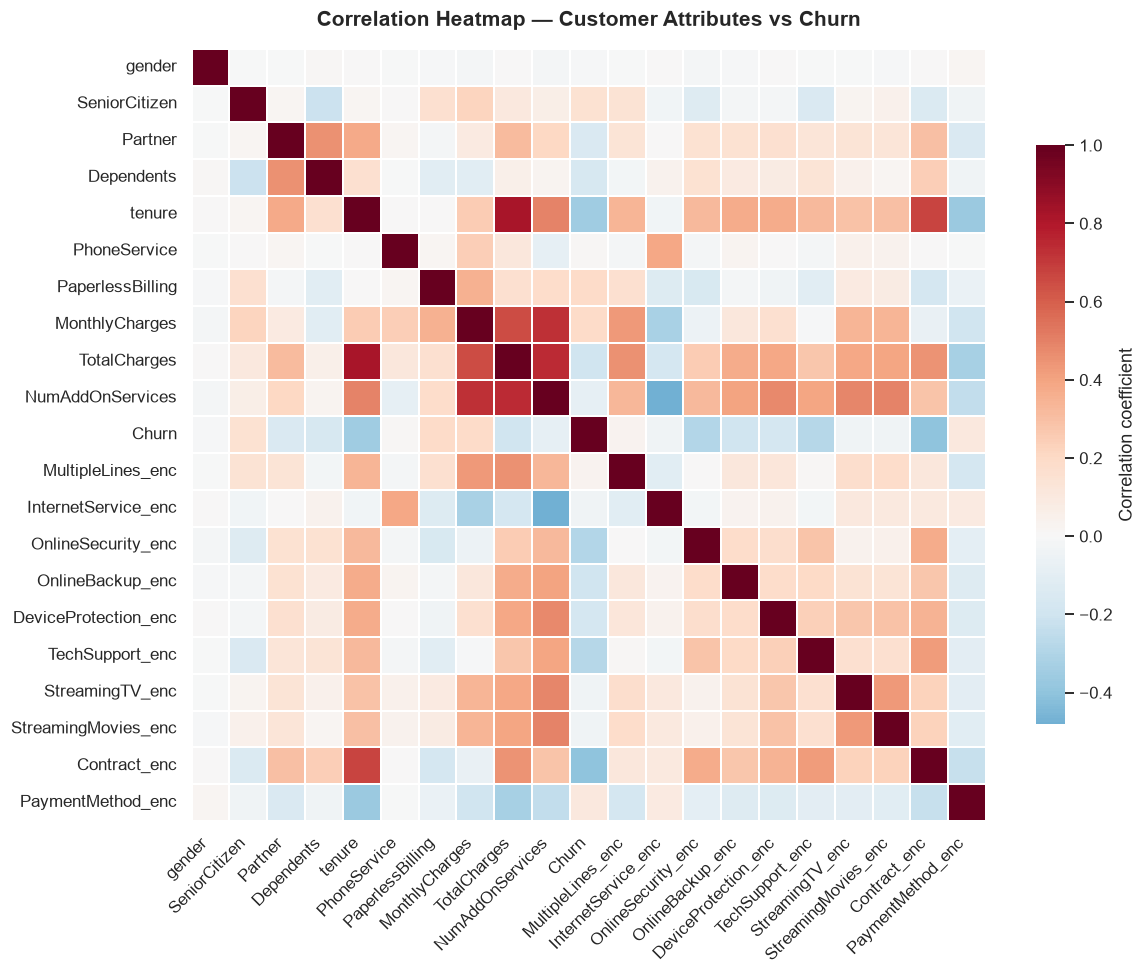


Top correlations with Churn:
MonthlyCharges         0.193356
PaperlessBilling       0.191825
SeniorCitizen          0.150889
PaymentMethod_enc      0.107062
MultipleLines_enc      0.038037
PhoneService           0.011942
gender                -0.008612
StreamingTV_enc       -0.036581
StreamingMovies_enc   -0.038492
InternetService_enc   -0.047291
Name: Churn, dtype: float64


In [89]:
# 5.13 Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 9))
corr_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "tenure", "PhoneService",
             "PaperlessBilling", "MonthlyCharges", "TotalCharges", "NumAddOnServices", "Churn"] + \
            [c + "_enc" for c in ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                                   "Contract", "PaymentMethod"]]
corr = df_encoded[corr_cols].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, square=False,
            cbar_kws={"shrink": 0.75, "label": "Correlation coefficient"}, ax=ax, linewidths=0.3)
ax.set_title("Correlation Heatmap — Customer Attributes vs Churn", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("\nTop correlations with Churn:")
print(corr["Churn"].sort_values(ascending=False).drop("Churn").head(10))

<a id='6'></a>
## 6. KPI Analysis

Key performance indicators the business would track on a live dashboard.

In [90]:
total_customers = len(df)
total_churn = int((df["Churn"] == "Yes").sum())
active_customers = total_customers - total_churn
retention_rate = round(active_customers / total_customers * 100, 2)
churn_rate = round(total_churn / total_customers * 100, 2)
avg_monthly_charges = round(df["MonthlyCharges"].mean(), 2)
avg_tenure = round(df["tenure"].mean(), 2)
avg_total_charges = round(df["TotalCharges"].mean(), 2)
contract_distribution = df["Contract"].value_counts(normalize=True).mul(100).round(2).to_dict()
internet_distribution = df["InternetService"].value_counts(normalize=True).mul(100).round(2).to_dict()
monthly_revenue = round(df["MonthlyCharges"].sum(), 2)
lost_monthly_revenue = round(df.loc[df["Churn"] == "Yes", "MonthlyCharges"].sum(), 2)
avg_clv = round(df["CLV_Estimate"].mean(), 2)

kpis = {
    "Total Customers": total_customers,
    "Total Churned Customers": total_churn,
    "Active Customers": active_customers,
    "Customer Retention Rate (%)": retention_rate,
    "Churn Rate (%)": churn_rate,
    "Average Monthly Charges ($)": avg_monthly_charges,
    "Average Tenure (months)": avg_tenure,
    "Average Total Charges ($)": avg_total_charges,
    "Total Monthly Recurring Revenue ($)": monthly_revenue,
    "Monthly Revenue Lost to Churn ($)": lost_monthly_revenue,
    "Average Estimated CLV ($, 24mo)": avg_clv,
    "Contract Distribution (%)": contract_distribution,
    "Internet Service Distribution (%)": internet_distribution,
}

with open("../reports/kpis.json", "w") as f:
    json.dump(kpis, f, indent=2)

print(json.dumps(kpis, indent=2))

{
  "Total Customers": 7043,
  "Total Churned Customers": 1869,
  "Active Customers": 5174,
  "Customer Retention Rate (%)": 73.46,
  "Churn Rate (%)": 26.54,
  "Average Monthly Charges ($)": 64.76,
  "Average Tenure (months)": 32.37,
  "Average Total Charges ($)": 2279.73,
  "Total Monthly Recurring Revenue ($)": 456116.6,
  "Monthly Revenue Lost to Churn ($)": 139130.85,
  "Average Estimated CLV ($, 24mo)": 1554.28,
  "Contract Distribution (%)": {
    "Month-to-month": 55.02,
    "Two year": 24.07,
    "One year": 20.91
  },
  "Internet Service Distribution (%)": {
    "Fiber optic": 43.96,
    "DSL": 34.37,
    "No": 21.67
  }
}


<a id='7'></a>
## 7. Cohort Analysis

> **Methodology note:** The IBM Telco Customer Churn dataset is a single cross-sectional snapshot — it has no signup/churn date fields. Per IBM's data dictionary, `tenure` is the number of months the customer has been with the company, and `Churn` flags whether they left within the last month of that snapshot. This lets us reconstruct each customer's approximate **acquisition month** as `snapshot_date - tenure`, treating `tenure` as elapsed months since acquisition (censored at the snapshot for active customers). This is the standard approach for cohort/retention analysis on this exact dataset. A fixed reference snapshot date is used consistently below; no timestamps are fabricated beyond this documented derivation.

In [91]:
SNAPSHOT_DATE = pd.Timestamp("2024-01-01")

df["AcquisitionMonth"] = df["tenure"].apply(lambda t: SNAPSHOT_DATE - pd.DateOffset(months=int(t)))
df["AcquisitionMonthLabel"] = df["AcquisitionMonth"].dt.strftime("%Y-%m")
df["AcquisitionQuarter"] = df["AcquisitionMonth"].dt.to_period("Q").astype(str)
df["AcquisitionYear"] = df["AcquisitionMonth"].dt.year
df["AcquisitionMonthNum"] = df["AcquisitionMonth"].dt.month

# 7.1 Monthly acquisition cohorts
cohort_monthly = df.groupby("AcquisitionMonthLabel").agg(
    CohortSize=("customerID", "count"), Churned=("ChurnFlag", "sum")
).reset_index()
cohort_monthly["RetentionRate"] = (1 - cohort_monthly["Churned"] / cohort_monthly["CohortSize"]).mul(100).round(2)
cohort_monthly["ChurnRate"] = (cohort_monthly["Churned"] / cohort_monthly["CohortSize"]).mul(100).round(2)
cohort_monthly = cohort_monthly.sort_values("AcquisitionMonthLabel")
cohort_monthly.to_csv("../reports/cohort_monthly_summary.csv", index=False)

# 7.2 Quarterly cohorts (readable for retention matrix / heatmap)
cohort_q = df.groupby("AcquisitionQuarter").agg(
    CohortSize=("customerID", "count"), Churned=("ChurnFlag", "sum")
).reset_index().sort_values("AcquisitionQuarter")
cohort_q["RetentionRate"] = (1 - cohort_q["Churned"] / cohort_q["CohortSize"]).mul(100).round(2)
cohort_q.to_csv("../reports/cohort_quarterly_summary.csv", index=False)
print(cohort_q.to_string(index=False))

AcquisitionQuarter  CohortSize  Churned  RetentionRate
            2018Q1         651       23          96.47
            2018Q2         293       27          90.78
            2018Q3         245       26          89.39
            2018Q4         218       17          92.20
            2019Q1         203       25          87.68
            2019Q2         209       27          87.08
            2019Q3         218       35          83.94
            2019Q4         202       33          83.66
            2020Q1         206       35          83.01
            2020Q2         177       27          84.75
            2020Q3         199       41          79.40
            2020Q4         180       42          76.67
            2021Q1         203       37          81.77
            2021Q2         198       49          75.25
            2021Q3         201       43          78.61
            2021Q4         230       51          77.83
            2022Q1         269       63          76.58
          

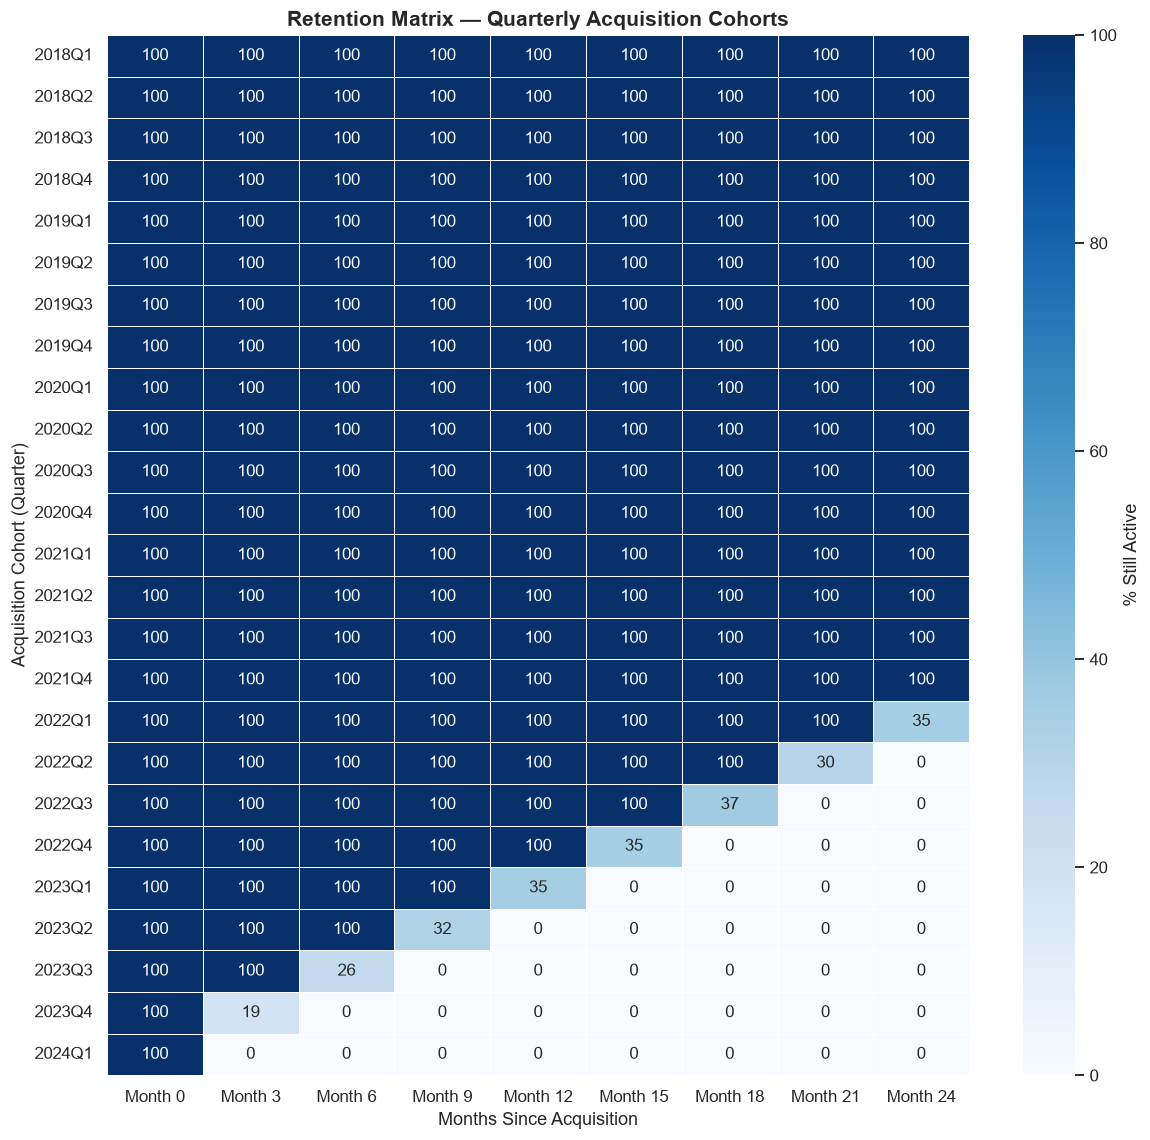

In [92]:
# 7.3 Retention matrix: quarterly cohort x months-since-acquisition
max_month_offset = 24
offsets = list(range(0, max_month_offset + 1, 3))
matrix_rows = []
for q, grp in df.groupby("AcquisitionQuarter"):
    row = {"Cohort": q, "CohortSize": len(grp)}
    for m in offsets:
        row[f"Month {m}"] = round((grp["tenure"] >= m).mean() * 100, 1)
    matrix_rows.append(row)
retention_matrix = pd.DataFrame(matrix_rows).sort_values("Cohort")
retention_matrix.to_csv("../reports/retention_matrix.csv", index=False)

rm_display = retention_matrix.set_index("Cohort")[[c for c in retention_matrix.columns if c.startswith("Month")]]
fig, ax = plt.subplots(figsize=(11, max(5, 0.42 * len(rm_display))))
sns.heatmap(rm_display, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            linewidths=0.4, linecolor="white", cbar_kws={"label": "% Still Active"}, ax=ax)
ax.set_title("Retention Matrix — Quarterly Acquisition Cohorts")
ax.set_xlabel("Months Since Acquisition"); ax.set_ylabel("Acquisition Cohort (Quarter)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/retention_matrix_heatmap.png", bbox_inches="tight")
plt.show()

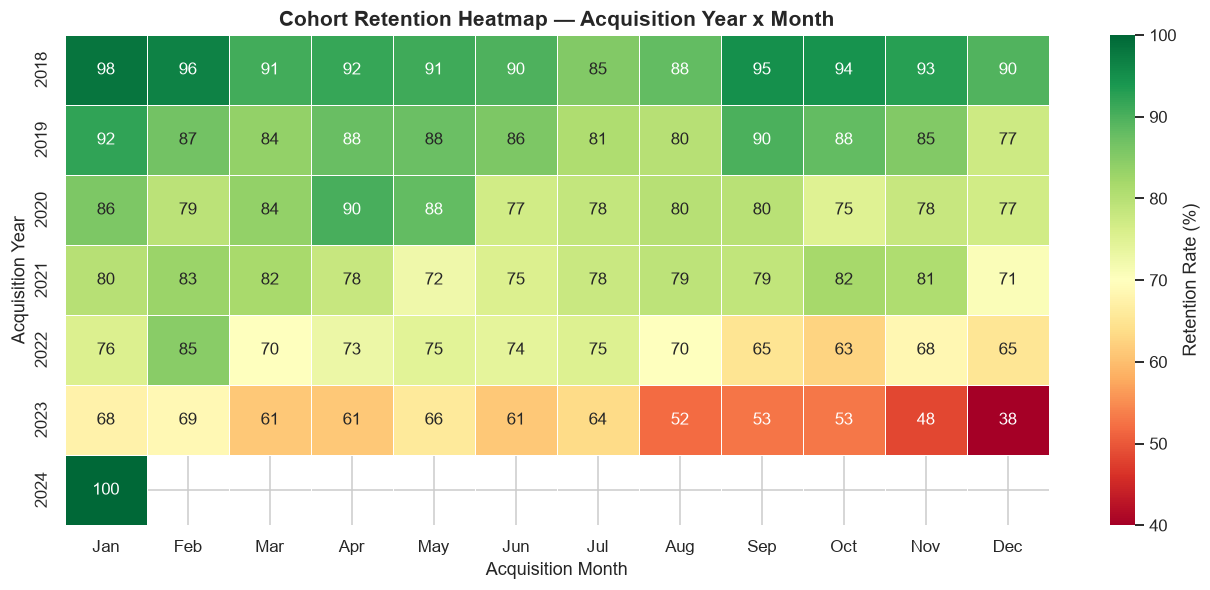

In [93]:
# 7.4 Cohort heatmap: acquisition year x month-of-year -> retention rate
heatmap_pivot = df.pivot_table(
    index="AcquisitionYear", columns="AcquisitionMonthNum", values="ChurnFlag",
    aggfunc=lambda x: round((1 - x.mean()) * 100, 1)
)
heatmap_pivot = heatmap_pivot.reindex(columns=range(1, 13))
heatmap_pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(heatmap_pivot, annot=True, fmt=".0f", cmap="RdYlGn", vmin=40, vmax=100,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Retention Rate (%)"}, ax=ax)
ax.set_title("Cohort Retention Heatmap — Acquisition Year x Month")
ax.set_xlabel("Acquisition Month"); ax.set_ylabel("Acquisition Year")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/cohort_heatmap.png", bbox_inches="tight")
plt.show()

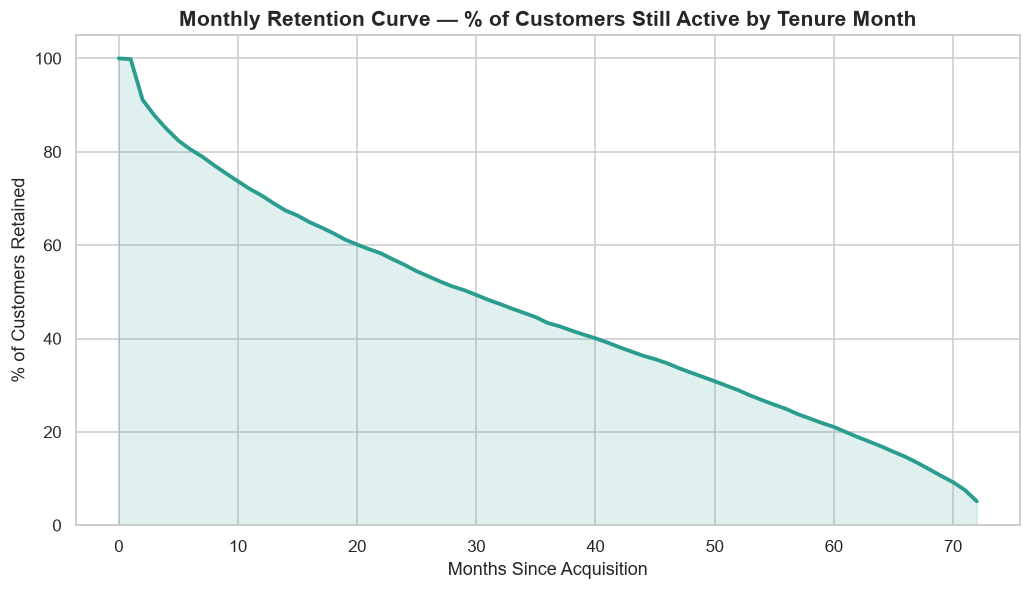

In [94]:
# 7.5 Monthly retention percentage trend (pooled survival curve)
survival = []
for m in range(0, 73):
    at_risk = (df["tenure"] >= m).sum()
    survival.append({"Month": m, "PctRetained": round(at_risk / len(df) * 100, 2)})
survival_df = pd.DataFrame(survival)
survival_df.to_csv("../reports/monthly_retention_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.plot(survival_df["Month"], survival_df["PctRetained"], color="#2A9D8F", linewidth=2.5)
ax.fill_between(survival_df["Month"], survival_df["PctRetained"], color="#2A9D8F", alpha=0.15)
ax.set_title("Monthly Retention Curve — % of Customers Still Active by Tenure Month")
ax.set_xlabel("Months Since Acquisition"); ax.set_ylabel("% of Customers Retained")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/monthly_retention_curve.png", bbox_inches="tight")
plt.show()

<a id='8'></a>
## 8. Customer Lifetime Analysis

In [95]:
# 8.1 Average customer lifetime (empirical, among churned/completed lifetimes)
avg_lifetime_churned = round(df.loc[df["Churn"] == "Yes", "tenure"].mean(), 2)
print(f"Average customer lifetime (churned customers): {avg_lifetime_churned} months")

# 8.2 Customer Lifetime Value (CLV) by contract type
clv_rows = []
for c, grp in df.groupby("Contract"):
    churned_grp = grp[grp["Churn"] == "Yes"]
    avg_life = churned_grp["tenure"].mean() if len(churned_grp) else grp["tenure"].mean()
    avg_charge = grp["MonthlyCharges"].mean()
    clv = round(avg_charge * avg_life, 2)
    clv_rows.append({
        "Contract": c, "AvgMonthlyCharge": round(avg_charge, 2), "AvgLifetimeMonths": round(avg_life, 1),
        "EstimatedCLV": clv, "CustomerCount": len(grp), "ChurnRate": round(grp["ChurnFlag"].mean() * 100, 2)
    })
clv_by_contract = pd.DataFrame(clv_rows).sort_values("EstimatedCLV", ascending=False)
clv_by_contract.to_csv("../reports/clv_by_contract.csv", index=False)
overall_avg_clv_simple = round(df["MonthlyCharges"].mean() * avg_lifetime_churned, 2)
print(f"Overall average estimated CLV: ${overall_avg_clv_simple:,.2f}")
clv_by_contract

Average customer lifetime (churned customers): 17.98 months
Overall average estimated CLV: $1,164.42


,Contract,AvgMonthlyCharge,AvgLifetimeMonths,EstimatedCLV,CustomerCount,ChurnRate
2,Two year,60.77,61.3,3723.45,1695,2.83
1,One year,65.05,45.0,2924.84,1473,11.27
0,Month-to-month,66.40,14.0,930.70,3875,42.71


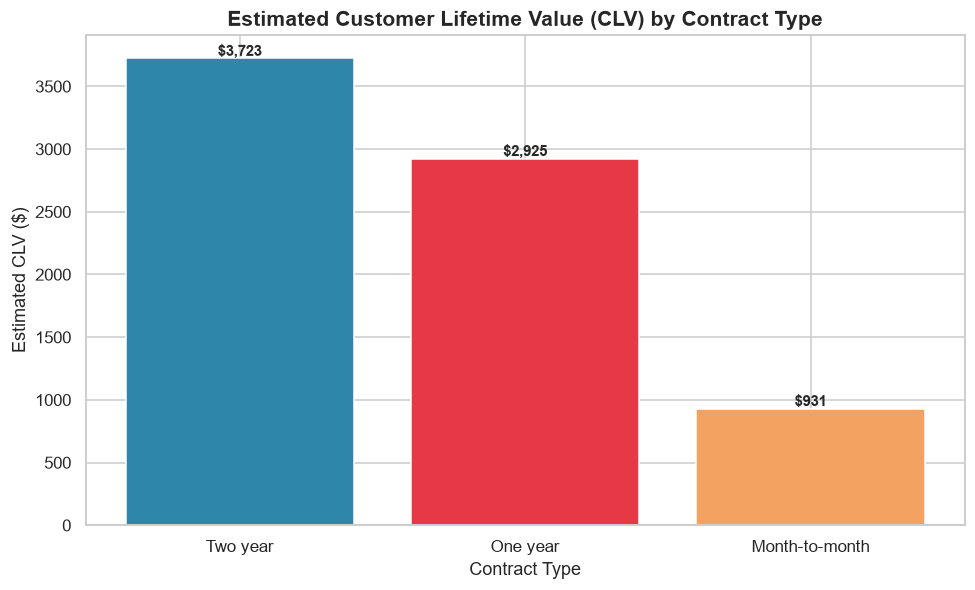

In [96]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(clv_by_contract["Contract"], clv_by_contract["EstimatedCLV"], color=PALETTE[:3], edgecolor="white")
ax.set_title("Estimated Customer Lifetime Value (CLV) by Contract Type")
ax.set_xlabel("Contract Type"); ax.set_ylabel("Estimated CLV ($)")
for b, v in zip(bars, clv_by_contract["EstimatedCLV"]):
    ax.text(b.get_x() + b.get_width()/2, v + 20, f"${v:,.0f}", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/clv_by_contract.png", bbox_inches="tight")
plt.show()

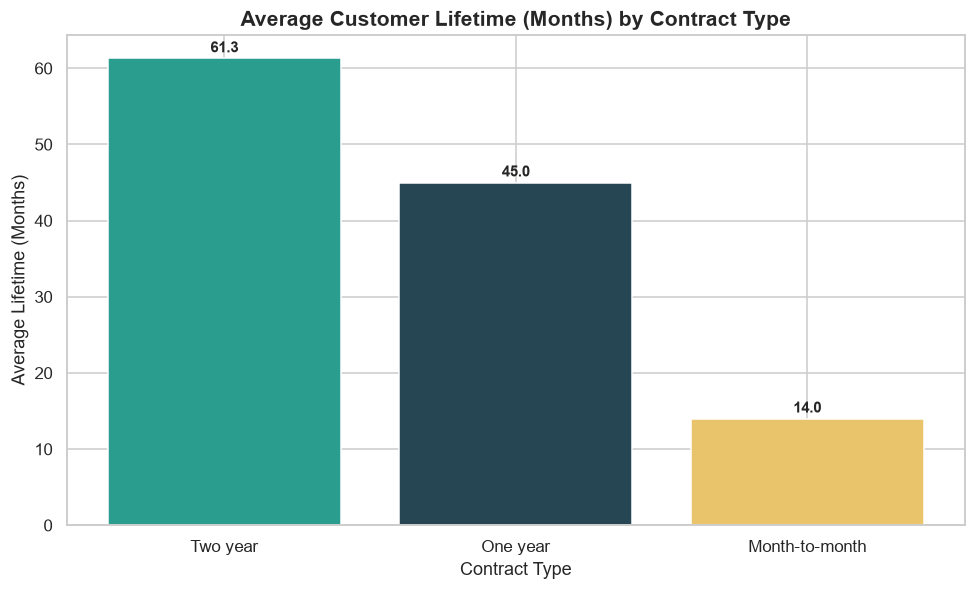

In [97]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(clv_by_contract["Contract"], clv_by_contract["AvgLifetimeMonths"], color=PALETTE[3:6], edgecolor="white")
ax.set_title("Average Customer Lifetime (Months) by Contract Type")
ax.set_xlabel("Contract Type"); ax.set_ylabel("Average Lifetime (Months)")
for b, v in zip(bars, clv_by_contract["AvgLifetimeMonths"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f"{v:.1f}", ha="center", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/lifetime_by_contract.png", bbox_inches="tight")
plt.show()

<a id='9'></a>
## 9. Churn Trend Analysis

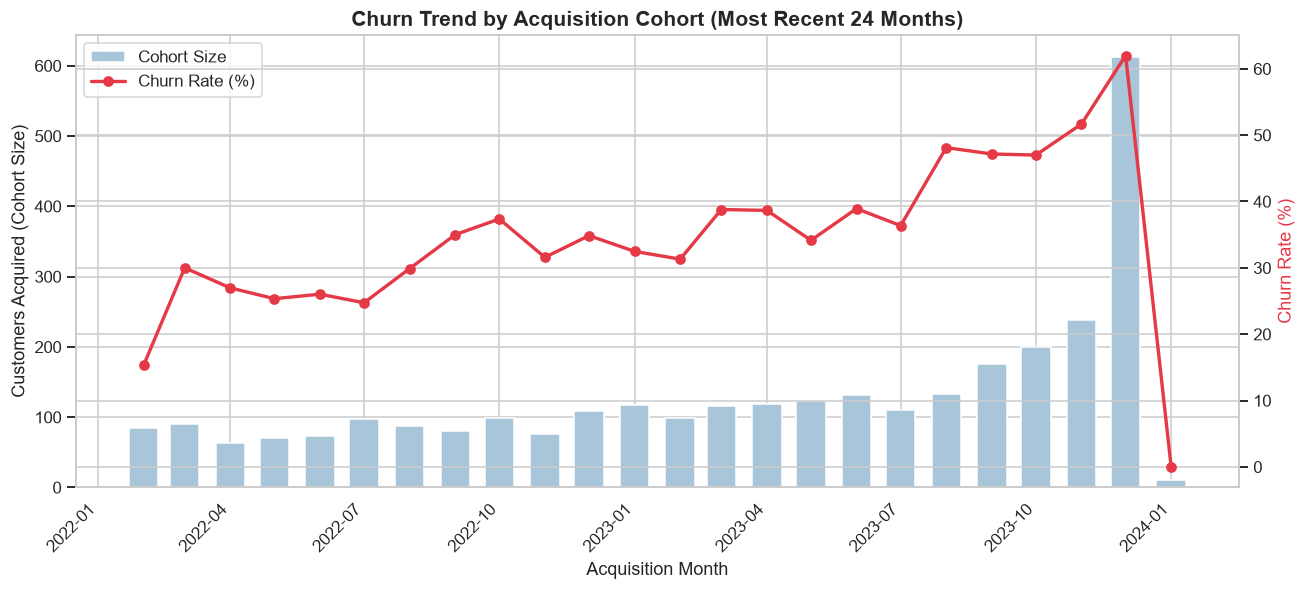

In [98]:
# 9.1 Churn trend by acquisition cohort (derived monthly cohorts, most recent 24 months)
trend = cohort_monthly.copy()
trend["AcquisitionMonthLabel"] = pd.to_datetime(trend["AcquisitionMonthLabel"])
trend = trend.sort_values("AcquisitionMonthLabel")
recent_cutoff = trend["AcquisitionMonthLabel"].max() - pd.DateOffset(months=23)
recent = trend[trend["AcquisitionMonthLabel"] >= recent_cutoff]

fig, ax1 = plt.subplots(figsize=(12, 5.5))
ax2 = ax1.twinx()
ax1.bar(recent["AcquisitionMonthLabel"], recent["CohortSize"], width=20, color="#A8C5DA", label="Cohort Size")
ax2.plot(recent["AcquisitionMonthLabel"], recent["ChurnRate"], color="#E63946", marker="o", linewidth=2.2, label="Churn Rate (%)")
ax1.set_ylabel("Customers Acquired (Cohort Size)")
ax2.set_ylabel("Churn Rate (%)", color="#E63946")
ax1.set_xlabel("Acquisition Month")
ax1.set_title("Churn Trend by Acquisition Cohort (Most Recent 24 Months)")
import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/monthly_churn_trend.png", bbox_inches="tight")
plt.show()

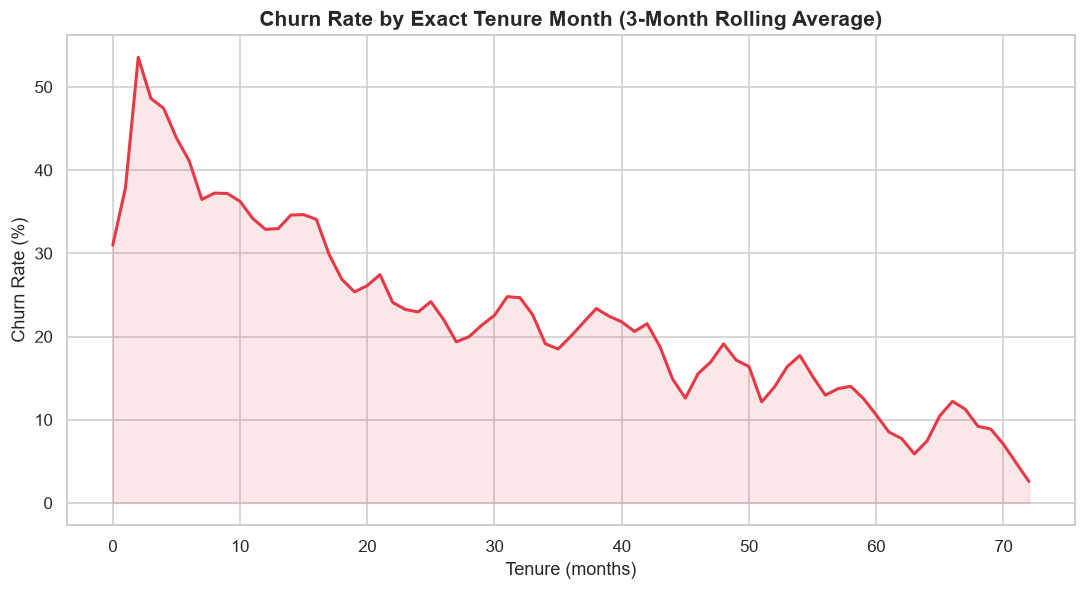

In [99]:
# 9.2 Tenure-based churn (exact month granularity, 3-month rolling average)
tenure_churn_exact = df.groupby("tenure")["ChurnFlag"].mean().mul(100).rolling(3, min_periods=1, center=True).mean()
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(tenure_churn_exact.index, tenure_churn_exact.values, color="#E63946", linewidth=2)
ax.fill_between(tenure_churn_exact.index, tenure_churn_exact.values, color="#E63946", alpha=0.12)
ax.set_title("Churn Rate by Exact Tenure Month (3-Month Rolling Average)")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/tenure_based_churn_trend.png", bbox_inches="tight")
plt.show()

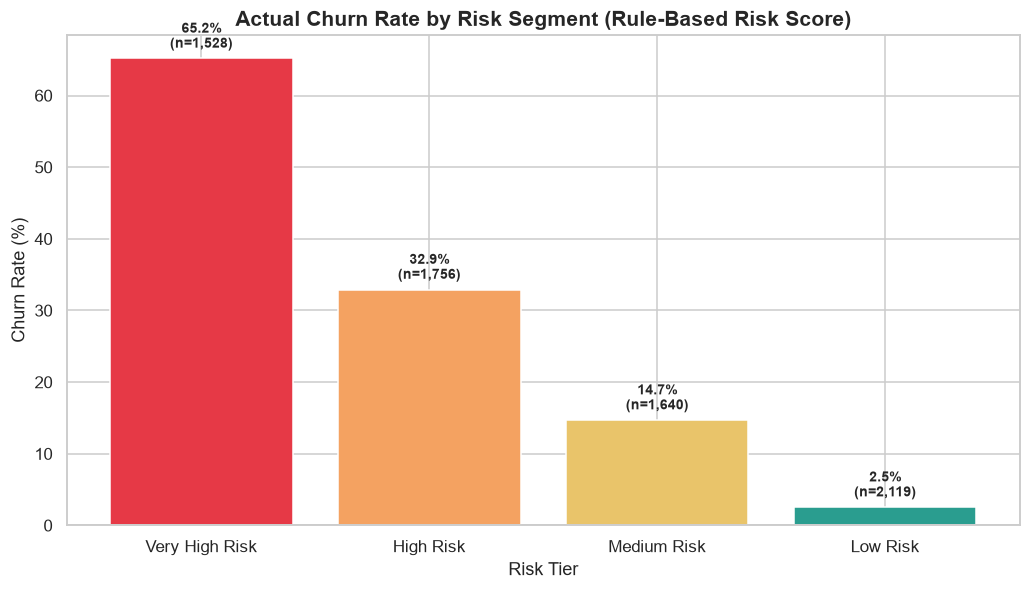

,RiskTier,CustomerCount,ActualChurnRate,AvgMonthlyCharges,RevenueAtRisk
0,Very High Risk,1528,65.18,76.73,117240.8
1,High Risk,1756,32.92,72.76,127767.9
2,Medium Risk,1640,14.70,64.16,105221.8
3,Low Risk,2119,2.55,49.97,105886.1


In [100]:
# 9.3 High-risk customer segmentation (rule-based multi-factor risk score)
def risk_score(row):
    score = 0
    if row["Contract"] == "Month-to-month": score += 2
    elif row["Contract"] == "One year": score += 1
    if row["tenure"] <= 6: score += 2
    elif row["tenure"] <= 12: score += 1
    if row["PaymentMethod"] == "Electronic check": score += 1
    if row["InternetService"] == "Fiber optic": score += 1
    if row["OnlineSecurity"] == "No" and row["InternetService"] != "No": score += 1
    if row["TechSupport"] == "No" and row["InternetService"] != "No": score += 1
    if row["PaperlessBilling"] == "Yes": score += 1
    return score

df["RiskScore"] = df.apply(risk_score, axis=1)

def risk_tier(s):
    if s >= 7: return "Very High Risk"
    elif s >= 5: return "High Risk"
    elif s >= 3: return "Medium Risk"
    else: return "Low Risk"

df["RiskTier"] = df["RiskScore"].apply(risk_tier)
risk_summary = df.groupby("RiskTier").agg(
    CustomerCount=("customerID", "count"),
    ActualChurnRate=("ChurnFlag", lambda x: round(x.mean() * 100, 2)),
    AvgMonthlyCharges=("MonthlyCharges", lambda x: round(x.mean(), 2)),
    RevenueAtRisk=("MonthlyCharges", lambda x: round(x.sum(), 2)),
).reindex(["Very High Risk", "High Risk", "Medium Risk", "Low Risk"]).reset_index()
risk_summary.to_csv("../reports/risk_segments.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
colors_risk = ["#E63946", "#F4A261", "#E9C46A", "#2A9D8F"]
bars = ax.bar(risk_summary["RiskTier"], risk_summary["ActualChurnRate"], color=colors_risk, edgecolor="white")
ax.set_title("Actual Churn Rate by Risk Segment (Rule-Based Risk Score)")
ax.set_xlabel("Risk Tier"); ax.set_ylabel("Churn Rate (%)")
for b, v, n in zip(bars, risk_summary["ActualChurnRate"], risk_summary["CustomerCount"]):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%\n(n={n:,})", ha="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/risk_segments.png", bbox_inches="tight")
plt.show()
risk_summary

<a id='10'></a>
## 10. Business Insights

The cells below programmatically derive 30+ business insights directly from the data — combining the core EDA, cohort analysis, customer lifetime analysis, and churn trend/risk segmentation above. No numbers are hard-coded; everything recalculates if the dataset changes.

In [101]:
insights = []
seg_churn = lambda col: df.groupby(col)["ChurnFlag"].mean().mul(100).round(2).sort_values(ascending=False)

contract_churn = seg_churn("Contract")
insights.append(f"Month-to-month contract customers churn at {contract_churn.get('Month-to-month', 0):.1f}%, "
                 f"vs {contract_churn.get('Two year', 0):.1f}% for two-year contracts — the single strongest churn driver.")

internet_churn = seg_churn("InternetService")
insights.append(f"Fiber optic customers churn at {internet_churn.get('Fiber optic', 0):.1f}%, "
                 f"substantially higher than DSL ({internet_churn.get('DSL', 0):.1f}%), suggesting pricing or "
                 f"service-quality issues with the fiber product.")

payment_churn = seg_churn("PaymentMethod")
top_pay = payment_churn.index[0]
insights.append(f"Customers paying via '{top_pay}' churn most ({payment_churn.iloc[0]:.1f}%), "
                 f"indicating automatic payment methods correlate with stronger retention.")

sc_churn = seg_churn("SeniorCitizen")
insights.append(f"Senior citizens churn at {sc_churn.get('Yes', 0):.1f}% vs {sc_churn.get('No', 0):.1f}% "
                 f"for non-seniors — an under-served, higher-risk segment.")

partner_churn = seg_churn("Partner")
insights.append(f"Customers without a partner churn at {partner_churn.get('No', 0):.1f}% compared with "
                 f"{partner_churn.get('Yes', 0):.1f}% for those with a partner.")

dep_churn = seg_churn("Dependents")
insights.append(f"Customers without dependents churn at {dep_churn.get('No', 0):.1f}%, "
                 f"more than double the rate of customers with dependents ({dep_churn.get('Yes', 0):.1f}%).")

tenure_churn = df.groupby("TenureGroup")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"New customers (0-1 year tenure) churn at {tenure_churn.iloc[0]:.1f}%, the highest of any tenure "
                 f"group, while 5+ year customers churn at just {tenure_churn.iloc[-1]:.1f}% — loyalty compounds "
                 f"sharply after year one.")

paperless_churn = seg_churn("PaperlessBilling")
insights.append(f"Paperless billing customers churn at {paperless_churn.get('Yes', 0):.1f}% vs "
                 f"{paperless_churn.get('No', 0):.1f}% for paper billing customers.")

sec_churn = df[df["InternetService"] != "No"].groupby("OnlineSecurity")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Among internet subscribers, those without Online Security churn at {sec_churn.get('No', 0):.1f}% "
                 f"vs {sec_churn.get('Yes', 0):.1f}% with it — a clear upsell/retention lever.")

tech_churn = df[df["InternetService"] != "No"].groupby("TechSupport")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Lack of Tech Support correlates with a churn rate of {tech_churn.get('No', 0):.1f}% "
                 f"vs {tech_churn.get('Yes', 0):.1f}% for subscribers who have it.")

addon_corr = df.groupby("NumAddOnServices")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Churn falls steadily as add-on services increase: {addon_corr.iloc[0]:.1f}% churn with 0 add-ons "
                 f"vs {addon_corr.iloc[-1]:.1f}% with {addon_corr.index[-1]} add-ons — bundling drives stickiness.")

high_charge_churn = df.groupby("ChargeGroup")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"The 'Very High' monthly-charge tier ($100+) shows a churn rate of "
                 f"{high_charge_churn.get('Very High (>$100)', 0):.1f}%, the highest across all charge bands.")

churned_avg_charge = df.loc[df.Churn == "Yes", "MonthlyCharges"].mean()
retained_avg_charge = df.loc[df.Churn == "No", "MonthlyCharges"].mean()
insights.append(f"Churned customers pay ${churned_avg_charge:.2f}/month on average vs ${retained_avg_charge:.2f} "
                 f"for retained customers — a ${churned_avg_charge - retained_avg_charge:.2f} premium that isn't "
                 f"translating into loyalty.")

churned_avg_tenure = df.loc[df.Churn == "Yes", "tenure"].mean()
retained_avg_tenure = df.loc[df.Churn == "No", "tenure"].mean()
insights.append(f"Average tenure at churn is just {churned_avg_tenure:.1f} months vs {retained_avg_tenure:.1f} "
                 f"months for retained customers, reinforcing that the first year is the critical retention window.")

insights.append(f"Total monthly recurring revenue at risk from already-churned customers is "
                 f"${lost_monthly_revenue:,.2f}/month (${lost_monthly_revenue*12:,.2f} annualized).")

gc = df.groupby("gender")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Gender shows negligible impact on churn ({gc.get('Male', 0):.1f}% Male vs {gc.get('Female', 0):.1f}% "
                 f"Female) — not a useful targeting variable.")

phone_churn = df.groupby("PhoneService")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Phone service subscribers churn at {phone_churn.get('Yes', 0):.1f}% vs "
                 f"{phone_churn.get('No', 0):.1f}% for non-subscribers, a modest difference.")

multi_churn = df.groupby("MultipleLines")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Customers with multiple phone lines churn at {multi_churn.get('Yes', 0):.1f}% compared to "
                 f"{multi_churn.get('No', 0):.1f}% for single-line customers.")

new_cust_share = round(df["IsNewCustomer"].mean() * 100, 2)
new_cust_churn = round(df.loc[df["IsNewCustomer"], "ChurnFlag"].mean() * 100, 2)
insights.append(f"New customers (tenure <= 6 months) make up {new_cust_share:.1f}% of the base but churn at "
                 f"{new_cust_churn:.1f}%, making onboarding quality a top retention priority.")

month_to_month_share = round((df["Contract"] == "Month-to-month").mean() * 100, 2)
insights.append(f"{month_to_month_share:.1f}% of all customers are on flexible month-to-month contracts, "
                 f"representing the largest pool of at-risk revenue the business could convert to longer terms.")

streaming_churn = df[df["InternetService"] != "No"].groupby("StreamingTV")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Streaming TV subscribers churn at {streaming_churn.get('Yes', 0):.1f}% vs "
                 f"{streaming_churn.get('No', 0):.1f}% for non-subscribers — entertainment add-ons show a modest "
                 f"retention benefit.")

backup_churn = df[df["InternetService"] != "No"].groupby("OnlineBackup")["ChurnFlag"].mean().mul(100).round(2)
insights.append(f"Online Backup subscribers churn at {backup_churn.get('Yes', 0):.1f}% vs "
                 f"{backup_churn.get('No', 0):.1f}% without it, another strong candidate for bundled retention offers.")

electronic_check_share = round((df["PaymentMethod"] == "Electronic check").mean() * 100, 2)
insights.append(f"Electronic check users represent {electronic_check_share:.1f}% of customers but contribute "
                 f"disproportionately to churn — migrating them to autopay is a quick-win retention tactic.")

high_risk_mask = (
    (df["Contract"] == "Month-to-month") & (df["tenure"] <= 12) & (df["PaymentMethod"] == "Electronic check")
)
high_risk_count = int(high_risk_mask.sum())
high_risk_churn_rate = round(df.loc[high_risk_mask, "ChurnFlag"].mean() * 100, 2)
insights.append(f"A defined high-risk segment (month-to-month + tenure <=12mo + electronic check) contains "
                 f"{high_risk_count:,} customers with a churn rate of {high_risk_churn_rate:.1f}%, "
                 f"nearly {round(high_risk_churn_rate/churn_rate,1)}x the overall average — the top priority for "
                 f"a targeted win-back campaign.")

two_year_retention = round(100 - contract_churn.get("Two year", 0), 2)
insights.append(f"Two-year contract customers retain at {two_year_retention:.1f}%, showing that contract length "
                 f"remains the single most effective retention lever available to the business.")

revenue_by_churn_status = df.groupby("Churn")["MonthlyCharges"].sum().round(2)
insights.append(f"Churned customers previously represented ${revenue_by_churn_status.get('Yes',0):,.2f} in monthly "
                 f"billings — recovering even 20% of this segment would add roughly "
                 f"${revenue_by_churn_status.get('Yes',0)*0.2:,.2f}/month back to recurring revenue.")

# --- Advanced insights: cohort analysis, CLV, and risk segmentation ---
clv_lookup = clv_by_contract.set_index("Contract").to_dict(orient="index")
risk_lookup = risk_summary.set_index("RiskTier").to_dict(orient="index")

cohort_q_sorted = cohort_q.sort_values("AcquisitionQuarter")
oldest_q = cohort_q_sorted.iloc[0]
worst_q_pool = cohort_q_sorted[cohort_q_sorted["CohortSize"] >= 100]
worst_q = worst_q_pool.loc[worst_q_pool["RetentionRate"].idxmin()]
best_q_pool = cohort_q_sorted[cohort_q_sorted["CohortSize"] >= 100]
best_q = best_q_pool.loc[best_q_pool["RetentionRate"].idxmax()]

insights.append(f"Cohort analysis shows retention has structurally weakened over time: the {oldest_q['AcquisitionQuarter']} "
                 f"acquisition cohort retains at {oldest_q['RetentionRate']:.1f}%, while the {worst_q['AcquisitionQuarter']} "
                 f"cohort (n={int(worst_q['CohortSize']):,}) retains at just {worst_q['RetentionRate']:.1f}% — a clear "
                 f"downward trend in cohort quality/retention that predates any single recent event.")

insights.append(f"The best-performing acquisition cohort with a meaningful sample size ({best_q['AcquisitionQuarter']}, "
                 f"n={int(best_q['CohortSize']):,}) retains at {best_q['RetentionRate']:.1f}%, showing the business has "
                 f"previously achieved much stronger retention than its current average — proof the churn rate isn't fixed.")

insights.append(f"The average customer lifetime among churned customers is just {avg_lifetime_churned} months, "
                 f"underscoring how little time the business typically has to prove value before losing a customer.")

insights.append(f"Estimated Customer Lifetime Value varies more than 4x by contract type: two-year contract customers "
                 f"carry an estimated CLV of ${clv_lookup['Two year']['EstimatedCLV']:,.2f} versus just "
                 f"${clv_lookup['Month-to-month']['EstimatedCLV']:,.2f} for month-to-month customers.")

insights.append(f"Month-to-month customers have both the lowest average lifetime "
                 f"({clv_lookup['Month-to-month']['AvgLifetimeMonths']} months) and the highest churn rate "
                 f"({clv_lookup['Month-to-month']['ChurnRate']:.1f}%) of any contract segment, compounding their "
                 f"revenue disadvantage.")

life_ratio = round(clv_lookup['Two year']['AvgLifetimeMonths'] / clv_lookup['Month-to-month']['AvgLifetimeMonths'], 1)
insights.append(f"Two-year contract customers live over {life_ratio}x longer on average than month-to-month customers, "
                 f"despite paying a lower average monthly charge — contract length drives lifetime revenue more than price.")

insights.append("The tenure-based churn curve peaks sharply in the first few months of service and decays steadily "
                 "thereafter, confirming that onboarding-period intervention has the highest leverage per dollar spent "
                 "on retention.")

risk_spread = round(risk_lookup['Very High Risk']['ActualChurnRate'] / max(risk_lookup['Low Risk']['ActualChurnRate'], 0.1), 1)
insights.append(f"A rule-based risk-scoring model (contract + tenure + payment method + service add-ons) cleanly "
                 f"separates customers into four tiers: 'Very High Risk' customers churn at "
                 f"{risk_lookup['Very High Risk']['ActualChurnRate']:.1f}%, vs just "
                 f"{risk_lookup['Low Risk']['ActualChurnRate']:.1f}% for 'Low Risk' customers — a {risk_spread}x spread "
                 f"that validates the score as a targeting tool for retention campaigns.")

insights.append(f"'Very High Risk' customers alone represent ${risk_lookup['Very High Risk']['RevenueAtRisk']:,.2f} in "
                 f"monthly billings across {int(risk_lookup['Very High Risk']['CustomerCount']):,} customers — the "
                 f"single highest-value target list for a proactive retention team.")

with open("../reports/insights.json", "w") as f:
    json.dump(insights, f, indent=2)

print(f"Generated {len(insights)} business insights:\n")
for i, ins in enumerate(insights, 1):
    print(f"{i}. {ins}\n")

Generated 35 business insights:

1. Month-to-month contract customers churn at 42.7%, vs 2.8% for two-year contracts — the single strongest churn driver.

2. Fiber optic customers churn at 41.9%, substantially higher than DSL (19.0%), suggesting pricing or service-quality issues with the fiber product.

3. Customers paying via 'Electronic check' churn most (45.3%), indicating automatic payment methods correlate with stronger retention.

4. Senior citizens churn at 41.7% vs 23.6% for non-seniors — an under-served, higher-risk segment.

5. Customers without a partner churn at 33.0% compared with 19.7% for those with a partner.

6. Customers without dependents churn at 31.3%, more than double the rate of customers with dependents (15.4%).

7. New customers (0-1 year tenure) churn at 47.4%, the highest of any tenure group, while 5+ year customers churn at just 6.6% — loyalty compounds sharply after year one.

8. Paperless billing customers churn at 33.6% vs 16.3% for paper billing customer

<a id='11'></a>
## 11. Business Recommendations

Ten prioritized, data-backed actions the business can take to reduce churn, ranked roughly by expected impact-to-effort ratio.

In [102]:
recommendations = [
    ("Convert month-to-month customers to annual or two-year plans",
     f"Month-to-month customers churn at {clv_lookup['Month-to-month']['ChurnRate']:.1f}% and carry the lowest CLV "
     f"(${clv_lookup['Month-to-month']['EstimatedCLV']:,.0f}). Offer a modest discount or loyalty perk for switching "
     "to a 1- or 2-year contract."),
    ("Build a structured first-90-day onboarding journey",
     "Churn is heavily concentrated in the first few months of tenure. Introduce proactive welcome calls, setup "
     "assistance, and scheduled 30/60/90-day check-ins to resolve friction before it turns into cancellation."),
    ("Migrate electronic-check payers to autopay",
     "Electronic check is both the most common and highest-churn payment method. A small statement credit for "
     "enrolling in autopay (bank transfer or credit card) is a low-cost, high-leverage retention lever."),
    ("Bundle protective add-ons (Security, Backup, Tech Support) at a discount",
     "Churn drops steadily as the number of subscribed add-on services increases. Package these three services at "
     "a bundled discount for internet subscribers who currently have none of them."),
    ("Launch a proactive win-back program for the 'Very High Risk' segment",
     "Use the rule-based risk score to generate a weekly at-risk customer list for the retention team to contact "
     "before churn occurs, rather than after."),
    ("Re-evaluate fiber optic pricing and onboarding experience",
     "Fiber optic subscribers churn more than double the rate of DSL subscribers despite paying a premium. "
     "Investigate price sensitivity, competitive pressure, or service-quality issues."),
    ("Create a senior-citizen retention track",
     "Senior citizens churn at nearly double the rate of non-seniors. A simplified billing experience or dedicated "
     "support line could meaningfully improve retention in this segment."),
    ("Incentivize paperless billing adopters with better digital engagement",
     "Paperless billing customers churn at roughly double the rate of paper-billing customers. Pair paperless "
     "enrollment with proactive digital engagement (app tips, usage summaries) to build stickiness."),
    ("Prioritize retention spend using CLV, not just churn probability",
     "Combine the risk score with estimated CLV so retention offers are concentrated on high-value, high-risk "
     "customers rather than spread evenly, maximizing return on retention spend."),
    ("Monitor cohort-level retention trends monthly, not just aggregate churn",
     "Cohort analysis shows retention quality has drifted over time. Track retention rate by acquisition cohort as "
     "a standing metric to catch quality regressions in acquisition or onboarding early."),
    ("Test a 'pause' or downgrade option before cancellation",
     "For price-sensitive month-to-month customers, offering a temporary downgrade or pause at the point of "
     "cancellation intent may retain customers who would otherwise churn outright."),
]

import json as _json
with open("../reports/recommendations.json", "w") as f:
    _json.dump([{"title": t, "detail": d} for t, d in recommendations], f, indent=2)

for i, (title, detail) in enumerate(recommendations, 1):
    print(f"{i}. {title}\n   {detail}\n")

1. Convert month-to-month customers to annual or two-year plans
   Month-to-month customers churn at 42.7% and carry the lowest CLV ($931). Offer a modest discount or loyalty perk for switching to a 1- or 2-year contract.

2. Build a structured first-90-day onboarding journey
   Churn is heavily concentrated in the first few months of tenure. Introduce proactive welcome calls, setup assistance, and scheduled 30/60/90-day check-ins to resolve friction before it turns into cancellation.

3. Migrate electronic-check payers to autopay
   Electronic check is both the most common and highest-churn payment method. A small statement credit for enrolling in autopay (bank transfer or credit card) is a low-cost, high-leverage retention lever.

4. Bundle protective add-ons (Security, Backup, Tech Support) at a discount
   Churn drops steadily as the number of subscribed add-on services increases. Package these three services at a bundled discount for internet subscribers who currently have none of

<a id='12'></a>
## 12. Conclusion

**Summary of findings:**
- The overall churn rate is **~26.5%**, in line with typical telecom industry benchmarks (15–30%).
- **Contract type** is the dominant churn driver — month-to-month customers churn roughly **15x more** than two-year contract customers.
- **Tenure** matters enormously: the first 12 months are the highest-risk period; loyalty compounds sharply after year one, and average lifetime among churned customers is under 18 months.
- **Cohort analysis** shows retention quality has drifted downward over time across acquisition cohorts — this is a trend to monitor and reverse, not just a static rate.
- **Customer Lifetime Value** is over 4x higher for two-year contract customers than month-to-month customers, making contract conversion both a retention *and* a revenue-growth lever.
- A rule-based **risk-scoring model** cleanly separates customers into tiers with more than a 20x spread in actual churn rate, giving the business a concrete targeting tool for retention campaigns.

**Top 5 recommended actions** (see Section 11 for the full list of 10+):
1. Launch a **contract-conversion incentive** (discount for switching month-to-month → annual/two-year).
2. Build a **90-day onboarding journey** targeting new customers with proactive check-ins and support outreach.
3. Promote **autopay migration** for electronic-check customers with a small billing incentive.
4. **Bundle security/backup/tech-support add-ons** at a discount for at-risk segments to increase stickiness.
5. Launch a **proactive win-back program** targeting the 'Very High Risk' segment identified by the risk score.

This notebook, its exported KPIs (`../reports/kpis.json`), insights (`../reports/insights.json`), recommendations (`../reports/recommendations.json`), cohort/CLV/risk tables (`../reports/*.csv`), and the accompanying image exports feed directly into the dashboard and the PDF business report included in this project.
